# Config

In [1]:
'''#MOana specific
import os, subprocess
print("PID:", os.getpid())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("hostname:", subprocess.run(["hostname"], capture_output=True, text=True).stdout.strip())
print(subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True).stdout)
'''

'#MOana specific\nimport os, subprocess\nprint("PID:", os.getpid())\nprint("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))\nprint("hostname:", subprocess.run(["hostname"], capture_output=True, text=True).stdout.strip())\nprint(subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True).stdout)\n'

In [2]:
#MOANA ONLY
'''
#os.environ["CUDA_VISIBLE_DEVICES"] = "1"
#check for errors
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
'''

'\n#os.environ["CUDA_VISIBLE_DEVICES"] = "1"\n#check for errors\nos.environ["CUDA_LAUNCH_BLOCKING"] = "1"\n'

In [3]:
import time

_timers = {}

def timer_start(name="default"):
    _timers[name] = time.perf_counter()

def timer_end(name="default"):
    dt = time.perf_counter() - _timers.pop(name)
    print(f"[{name}] {dt:.2f}s")
    return dt
timer_start()

In [2]:
# Cell 0 — CONFIG
#case
case_name = "402_Hide_n_seek_sw07"
experiment = "v_05"
asset_name = f"{case_name}_{experiment}"
import json
from pathlib import Path
import numpy as np
%load_ext autoreload
%autoreload 2
import sys, os
from dotenv import load_dotenv
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))  # only path this notebook sets; A_Config adds the rest on import
from A_Config import (
    set_case, case_dir, source_dir, query_dir, sam3_masks_dir,
    frames_for_cam_poses_dir, frames_for_recon_dir, vggt_o_output_dir,
    predictions_path, ply_dir, reg_dir, csv_path_gps, csv_path_pose,
    assets_dir, recon_for_MAP_dir,recon_for_EVENT_dir
)

print("project_root:", project_root)
print(project_root, project_root.exists())
load_dotenv(project_root / ".env")

set_case(case_name, experiment)

case_dir_ = case_dir()
source_dir_ = source_dir()
query_dir_ = query_dir()
masks_dir = sam3_masks_dir()
# These two are the PARENT stage folders. Each recon's own frame set now lives in a
# beat-keyed subfolder of them, handed out by build_recon_requests as job["frames_dir"].
frames_for_cam_poses = frames_for_cam_poses_dir()

frames_for_recon = frames_for_recon_dir()
VGGT_O_output_dir = vggt_o_output_dir()#used until 15 aug
ply_dir_ = ply_dir()
reg_dir_ = reg_dir()
csv_path_GPS = csv_path_gps()
csv_path_pose_ = csv_path_pose()

FRAME_NAME_FMT = "{:04d}.jpg"
# video loading
from Two2D.B_video_processing import video_fps
# Auto-find the video in 010_source
videos = list(source_dir_.glob("*.mp4"))
print(source_dir_)
assert len(videos) == 1, f"Expected 1 video, found {len(videos)}: {videos}"
video_path = videos[0]
print(f"Case    : {case_name}")
print(f"Video   : {video_path.name}")
fps = video_fps(video_path)
print(f"video fps: {fps:.3f}")
import cv2; total_frames = int(cv2.VideoCapture(str(video_path)).get(cv2.CAP_PROP_FRAME_COUNT))
print("total_frames",total_frames )
#reporting
from C_CSV_report import add_to_report
overview = {
    "Video_name"      : video_path.name, 
    "Title"      : f"{case_name}_{experiment}"
}
add_to_report(overview)
api_key = os.getenv("STREETVIEW_API_KEY")

project_root: /workspace/project
/workspace/project True
/workspace/project/Data/402_Hide_n_seek_sw07/010_source
Case    : 402_Hide_n_seek_sw07
Video   : VID_20260815_165930783.mp4
video fps: 30.000
total_frames 7655


In [3]:
#FLAGS dict and 'producer dict
flags = {
    "VID_TO_TEXT": True,
    "TRACKING": False,
    "FRAME_SELECTION": True,
    "RECON_CAM_POSES": False,
    "RECON_3D": False,
    "GOOGLE_MAP": False,
    "BEV_MAP" : True,
    "PROJECTION_MAP": False,
    "MAKE_MOVIE": False,
    "MAKE_MOVIE_CUTS" : False,
    "MASK_OVERLAYS": False ,
    "PHYSICS_OVERLAYS" : False,
    "MULTICAM" : False
}
MENU_KEYS = {"TRACKING","RECON_CAM_POSES", "RECON_3D",
                          "GOOGLE_MAP", "BEV_MAP" , "PROJECTION_MAP", "MASK_OVERLAYS", "MULTICAM"}
producer_flags = {k: v for k, v in flags.items() if k in MENU_KEYS}

In [4]:
#2d ANALYSIS - JUST GPS now!
from D_2d_analysis import analysis_2D
analysis_2d_for_decisions = analysis_2D(video_path,  api_key)
print(analysis_2d_for_decisions)

{'GPS_signal': 'no'}


# AI First Pass
## Gem, vid to text

In [7]:
#turn a video into a text description
if flags["VID_TO_TEXT"] == True:
    from Two2D.A_gemini_v02 import gemini_vid_to_text
    gem_summaries = gemini_vid_to_text(video_path, case_name, query_dir())
else:
    print("Cell disabled")

re_caching video
Here is a detailed summary of the video:

From 00:00 to 00:33, the person filming counts to 10 to start a game of hide and seek.

From 00:33 to 01:05, the seeker walks around the garden and finds the first person hiding behind a tree.

From 01:05 to 01:37, the seeker continues searching and finds the second person hiding behind a bush.

From 01:37 to 02:08, the seeker continues searching and finds the third person hiding behind a wooden gate.

From 02:08 to 02:35, the seeker finds the fourth person hiding behind a bin, and then the fifth person hiding behind a brick wall.

From 02:35 to 04:16, the seeker goes through a gate to the driveway and finds the last three people hiding behind a bush.
[gemini-diag] summary: prompt_feedback=None
[gemini-diag] summary: candidate[0].finish_reason=FinishReason.STOP
[gemini-diag] summary: candidate[0].safety_ratings=None
The tree is visible from 00:36 to 00:40 and again from 00:54 to 01:05.

The bush in the garden is visible from 01

## Producer 1

In [5]:
Question = "Make a video summary of this video and show each person being found. track them, not the objects they are hiding behind."

In [17]:
#PRODUCER DRAFT 1
from claude_agent.producer_agent_execution import run_producer_agent, build_producer_prompt_draft1
prompt = build_producer_prompt_draft1(Question, analysis_2d_for_decisions, producer_flags)
paper_edit_json_path = run_producer_agent(prompt, mode ="draft")

[15:00:28 +  0.00s] run_producer_agent: start
[15:00:28 +  0.00s] thread: start
[15:00:28 +  0.00s] event loop: created
[15:00:28 +  0.00s] query: start
[15:01:20 + 51.78s] turn 1 usage (claude-sonnet-5): in=2 out=4 cache_write=4593 cache_read=12095
[15:01:20 + 51.78s] turn 1 content blocks: ['ThinkingBlock']
[15:01:20 + 51.78s] thinking:
I'm planning the draft structure: an opening counting beat, then an EVENT_ACTION beat for each found person, plus a map beat since there's no GPS data. Since the brief calls for tracking people rather than objects, each found beat needs mask overlays tied to the correct person ID, though matching people to their list appearances isn't entirely clear yet.

I'm trying to align each found-person timestamp with the corresponding hiding spot and appearance window -- tree, bush, gate, bin, brick wall -- working through the overlapping time ranges to figure out which person ID belongs to which beat.

But I notice person-1 keeps reappearing across many unrela

In [6]:
# DRAFT TIDY UP
# Re-run this cell on its own to regenerate the HTML/flags after editing and correct mistakes
import importlib
import json
import render_paper_edit
importlib.reload(render_paper_edit)
from render_paper_edit import render_and_save, derive_and_save_flags, paper_edit_path
restart = True
if restart == True:
    #2d ANALYSIS - JUST GPS now!
    from D_2d_analysis import analysis_2D
    analysis_2d_for_decisions = analysis_2D(video_path,  api_key)
    print(analysis_2d_for_decisions)

try:
    paper_edit_json_path  # from run_producer_agent, if the kernel still has it
except NameError:
    paper_edit_json_path = paper_edit_path()

html_path = render_and_save(paper_edit_json_path)
print(f"\n=== Rendered HTML ===\n  {html_path}")

flags_path = derive_and_save_flags(
    paper_edit_json_path, producer_flags.keys(), fps=fps,
    gps_signal=analysis_2d_for_decisions.get("GPS_signal"),
)
producer_output_flags = json.loads(flags_path.read_text(encoding="utf-8"))
flags.update(producer_output_flags)  # Producer owns MENU_KEYS; the rest stay operator-set
print(f"\n=== Derived flags (from {flags_path.name}) ===")
print(json.dumps(producer_output_flags, indent=2))

{'GPS_signal': 'no'}

=== Rendered HTML ===
  /workspace/project/Data/402_Hide_n_seek_sw07/012_agent_p_output/v_05/402_Hide_n_seek_sw07_draft_paper_edit.html
Paper edit flag corrections (feed back to Producer):
- Beat ['beat-02']: added TRACKING (Producer didn't request it).
- Beat ['beat-02']: added TRACKING (Producer didn't request it).
- Beat ['beat-03']: added TRACKING (Producer didn't request it).
- Beat ['beat-03']: added TRACKING (Producer didn't request it).
- Beat ['beat-05']: added TRACKING (Producer didn't request it).
- Beat ['beat-05']: added TRACKING (Producer didn't request it).
- Beat ['beat-06']: added TRACKING (Producer didn't request it).
- Beat ['beat-06']: added TRACKING (Producer didn't request it).
- Beat ['beat-07']: added TRACKING (Producer didn't request it).
- Beat ['beat-07']: added TRACKING (Producer didn't request it).
- Beat ['beat-09']: added TRACKING (Producer didn't request it).
- Beat ['beat-09']: added TRACKING (Producer didn't request it).

=== Deri

# Tracking

In [21]:
# TRACKING SAM3 PIPELINE

if flags["TRACKING"]:
    from run_models.A_ROBOFLOW_SAM3 import track_subject_sam3
  
    analysis_2d_for_decisions.update (track_subject_sam3(video_path)) # add to the dict
    tracker = "SAM3"
    print(analysis_2d_for_decisions)
else:
    print("Cell disabled")

here
accessing data
defaultdict(<class 'list'>, {})
initialising tracking (local SAM3)
[person] requested 53-65s -> keyframe-aligned start frame 1590


frame loading (OpenCV) [rank=0]: 100%|██████████| 365/365 [00:01<00:00, 275.70it/s]
INFO 2026-08-20 15:31:51,961 712048 sam3_base_predictor.py: 146: started new session d5e59d25-ae59-4c8f-aa0a-9fd561430b1e
propagate_in_video: 100%|██████████| 365/365 [01:27<00:00,  4.17it/s]
INFO 2026-08-20 15:33:19,799 712048 sam3_base_predictor.py: 305: propagation ended in session d5e59d25-ae59-4c8f-aa0a-9fd561430b1e
INFO 2026-08-20 15:33:20,085 712048 sam3_base_predictor.py: 409: removed session d5e59d25-ae59-4c8f-aa0a-9fd561430b1e


[person] requested 82-97s -> keyframe-aligned start frame 2460


frame loading (OpenCV) [rank=0]: 100%|██████████| 454/454 [00:01<00:00, 285.29it/s]
INFO 2026-08-20 15:33:48,253 712048 sam3_base_predictor.py: 146: started new session 0bd6001f-1f02-4880-a333-61c523564752
propagate_in_video: 100%|██████████| 454/454 [02:55<00:00,  2.59it/s]
INFO 2026-08-20 15:36:43,657 712048 sam3_base_predictor.py: 305: propagation ended in session 0bd6001f-1f02-4880-a333-61c523564752
INFO 2026-08-20 15:36:43,955 712048 sam3_base_predictor.py: 409: removed session 0bd6001f-1f02-4880-a333-61c523564752


[person] requested 101-123s -> keyframe-aligned start frame 3030
[local SAM3] 665 frames -> offloading video+state to CPU


...

[person] requested 135-155s -> keyframe-aligned start frame 4050


frame loading (OpenCV) [rank=0]: 100%|██████████| 603/603 [00:02<00:00, 291.04it/s]
INFO 2026-08-20 15:44:54,184 712048 sam3_base_predictor.py: 146: started new session badb6b3e-69b2-4d37-a9ac-20333457329e
propagate_in_video: 100%|██████████| 603/603 [05:22<00:00,  1.87it/s]
INFO 2026-08-20 15:50:16,901 712048 sam3_base_predictor.py: 305: propagation ended in session badb6b3e-69b2-4d37-a9ac-20333457329e
INFO 2026-08-20 15:50:17,538 712048 sam3_base_predictor.py: 398: empty_cache freed 11356078080 bytes (free_pct 4.4% -> 49.2%, reserved 23634903040 -> 12278824960 bytes)
INFO 2026-08-20 15:50:17,539 712048 sam3_base_predictor.py: 409: removed session badb6b3e-69b2-4d37-a9ac-20333457329e


[person] requested 241-252s -> keyframe-aligned start frame 7200


frame loading (OpenCV) [rank=0]: 100%|██████████| 353/353 [00:01<00:00, 259.06it/s]
INFO 2026-08-20 15:50:29,007 712048 sam3_base_predictor.py: 146: started new session 144b7ca1-0d3f-4b73-a2fc-ccf3c61f2412
propagate_in_video: 100%|██████████| 353/353 [03:05<00:00,  1.90it/s]
INFO 2026-08-20 15:53:35,257 712048 sam3_base_predictor.py: 305: propagation ended in session 144b7ca1-0d3f-4b73-a2fc-ccf3c61f2412
INFO 2026-08-20 15:53:35,542 712048 sam3_base_predictor.py: 409: removed session 144b7ca1-0d3f-4b73-a2fc-ccf3c61f2412


[local SAM3] released -- 10.34GiB still allocated
{'GPS_signal': 'no', 'person-01': {'Subject_frames_present': [1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1823, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866, 1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877, 1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954], 'subject_first_fr

In [22]:
pprint(analysis_2d_for_decisions)

Pretty printing has been turned OFF


In [23]:
#TRACKING SAM3 MANUAL controls
manual_sam = False
if manual_sam == True:
    from run_models.A_ROBOFLOW_SAM3 import track_subject_sam3, run_sam3_manual
    analysis_2d_for_decisions.update (run_sam3_manual(video_path, "person")) # add to the dict
    tracker = "SAM3"
    print(analysis_2d_for_decisions)

In [7]:
#Rebuild tracking after restart 
restart = True
if restart == True:
    from D_2d_analysis import analysis_2d_from_masks, analysis_2d_gemvsSAM
    from render_paper_edit import paper_edit_path
    from pprint import pprint

    try:
        paper_edit_json_path  # from run_producer_agent, if the kernel still has it
    except NameError:
        paper_edit_json_path = paper_edit_path()

    #noun phrases form paper edit vs masks
    analysis_2d_for_decisions.update(analysis_2d_from_masks(paper_edit_json_path))  # non-person subjects, from mask folders
    #Gemini people from paper edit  VS sam csv
    pprint(analysis_2d_for_decisions)

/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'GPS_signal': 'no',
 'person-01': {'Subject_frames_present': [1810,
                                          1811,
                                          1812,
                                          1813,
                                          1814,
                                          1815,
                                          1816,
                                          1817,
                                          1818,
                                          1819,
                                          1820,
                                          1821,
                                          1822,
                                          1823,
                                          1824,
                                          1825,
                                          1826,
                                          1827,
                                          1828,
                                          1829,
                   

In [25]:
 
print(analysis_2d_for_decisions)

{'GPS_signal': 'no', 'person-01': {'Subject_frames_present': [1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1823, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866, 1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877, 1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954], 'subject_first_frame': 1810, 'subject_last_frame': 1954, 'subject_d

In [26]:
#MATCHING GEM VS SAM
from A_Config import source_video_path
from Two2D.B_video_processing import video_dims
from Two2D.AX_gem_SAM_matcher import gem_person_targets_lookup
from Two2D.AY_claude_crop_matcher import write_masked_crops, match_tracks_to_descriptors
from D_2d_analysis import analysis_2d_gemvsSAM

_, _, fps = video_dims(source_video_path())

crops = write_masked_crops()                                  # eyeball these first
match_results = match_tracks_to_descriptors(crops_by_track=crops, fps=fps)

Gem_SAM_tracking = analysis_2d_gemvsSAM(
    gem_person_targets=gem_person_targets_lookup(fps),         # beat_ids only
    match_results=match_results,                               # crops, not box IoU
)

[person-01] 10 crop(s) from 145 masked frames
[person-02] 10 crop(s) from 33 masked frames
[person-03] 10 crop(s) from 79 masked frames
[person-04] 10 crop(s) from 129 masked frames
[person-05] 9 crop(s) from 9 masked frames
[person-06] 10 crop(s) from 236 masked frames
[person-07] 10 crop(s) from 236 masked frames
[person-08] 10 crop(s) from 13 masked frames
[person-09] 10 crop(s) from 137 masked frames
[person-10] 10 crop(s) from 99 masked frames
[person-11] 3 crop(s) from 3 masked frames
[person-12] 10 crop(s) from 15 masked frames
[person-13] 10 crop(s) from 15 masked frames
[person-14] 10 crop(s) from 94 masked frames
[person-15] 10 crop(s) from 149 masked frames
[person-16] 10 crop(s) from 42 masked frames
[person-17] 8 crop(s) from 9 masked frames (1 under 1500px, skipped)
[person-18] 10 crop(s) from 250 masked frames
[person-19] 10 crop(s) from 211 masked frames
[person-20] 10 crop(s) from 162 masked frames
[person-21] 10 crop(s) from 16 masked frames
person-01 -> person-1
pers

# RECON
## Frame Selection

In [8]:
from render_paper_edit import build_recon_requests

recon_jobs = [j for j in build_recon_requests(fps=fps)
              if flags["RECON_CAM_POSES" if j["kind"] == "MAP" else "RECON_3D"]]

beat-04 MAP (RECON_CAM_POSES): 33-97s @ 30.0fps -> frames 990-2910
beat-08 MAP (RECON_CAM_POSES): 233-252s @ 30.0fps -> frames 6990-7560


In [9]:
#RECON JOBS - one per (beat, recon kind) the Producer asked for
# Replaces v06's single RECON_CAM_POSES window + single RECON_3D window. Every beat
# that asks for a recon gets its own: its own frame range, its own frames folder and
# its own recon folder, so several MAP and several EVENT recons live side by side.
# Max one of each kind per beat -- two recons of a kind means two beats.
# Each job dict is added to by the cells below; nothing here binds a global `recon`.
from render_paper_edit import build_recon_requests

recon_jobs = [j for j in build_recon_requests(fps=fps)
              if flags["RECON_CAM_POSES" if j["kind"] == "MAP" else "RECON_3D"]]

def jobs_of(kind=None, archetype=None, flag=None, beat_key=None):
    """The lookup every cell below uses instead of a single global recon variable.

    kind      -- which SOLVE this is: "MAP" (RECON_CAM_POSES, the camera track a
                 map is built from) or "EVENT" (RECON_3D, a moment of action).
    archetype -- what the BEAT is for: "MAP" for a beat that renders a map.
    These two are not the same thing -- a non-MAP beat can ask for either solve --
    so map rendering selects on archetype and physics work selects on kind.
    flag      -- something in the beat's own requested_flags, e.g. "BEV_MAP"."""
    return [j for j in recon_jobs
            if (kind is None or j["kind"] == kind)
            and (archetype is None or j["archetype"] == archetype)
            and (flag is None or flag in (j["beat"].get("requested_flags") or []))
            and (beat_key is None or j["beat_key"] == beat_key)]

print(f"{len(recon_jobs)} recon job(s)")
for job in recon_jobs:
    print(f"  {job['beat_key']:<10} {job['kind']:<6} frames {job['start_frame']}-{job['end_frame']}"
          f"  -> {job['recon_dir']}")


beat-04 MAP (RECON_CAM_POSES): 33-97s @ 30.0fps -> frames 990-2910
beat-08 MAP (RECON_CAM_POSES): 233-252s @ 30.0fps -> frames 6990-7560
2 recon job(s)
  beat-04    MAP    frames 990-2910  -> /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_05/beat-04
  beat-08    MAP    frames 6990-7560  -> /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_05/beat-08


In [30]:
#FRAME SELECTION - one frame set per recon job
# Same capacity/interval maths as v06, applied per job instead of once for the whole
# video: each beat's own window is thinned to `capacity` frames.
if flags["FRAME_SELECTION"] == True:
    from Two2D.B_video_processing import image_sequencer

    capacity  = 200      # frames one recon can hold
    window    = fps/2    # search window for sharpness
    min_sharp = 0.0      # raise this after inspecting selection_log.json

    for job in recon_jobs:
        span     = job["end_frame"] - job["start_frame"]
        skip     = (span + capacity - 1) // capacity     # frames to skip between samples
        interval = skip / fps                            # image_sequencer wants seconds
        print(f"{job['beat_key']} {job['kind']}: {span} frames, interval {skip}")

        results = image_sequencer(
            video_path    = str(video_path),
            output_dir    = str(job["frames_dir"]),
            interval_sec  = interval,
            search_window = window,
            min_sharpness = min_sharp,
            start_frame   = job["start_frame"],
            end_frame     = job["end_frame"],
        )
        print(f"  {len(results)} frames written to {job['frames_dir']}")
else:
    print("Cell disabled")


beat-04 MAP: 1918 frames, interval 10
Window  : clamped from ±14.986317521468642 to ±5 (half interval)
Video   : VID_20260815_165930783.mp4
          30 fps · 7655 frames · 255.4s
Range   : frames 989-2907 (1918 frames)
Sampling: every 10 frames (0.3336376660134988s) → 192 candidates
Window  : ±5 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 1918/1918 [00:07<00:00, 265.01fr/s]


Selected: 192 frames  (112 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 1918/1918 [00:06<00:00, 316.64fr/s]


Log     : /workspace/project/Data/402_Hide_n_seek_sw07/020_frames_for_cam_poses/v_05/beat-04/selection_log.json
Sharpness (at 25% res): min 284 · mean 6654 · max 18948
  2 frames written to /workspace/project/Data/402_Hide_n_seek_sw07/020_frames_for_cam_poses/v_05/beat-04
beat-08 MAP: 569 frames, interval 3
Window  : clamped from ±14.986317521468642 to ±1 (half interval)
Video   : VID_20260815_165930783.mp4
          30 fps · 7655 frames · 255.4s
Range   : frames 6984-7553 (569 frames)
Sampling: every 3 frames (0.10009129980404964s) → 190 candidates
Window  : ±1 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 569/569 [00:02<00:00, 268.06fr/s]


Selected: 190 frames  (48 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 569/569 [00:03<00:00, 181.60fr/s]

Log     : /workspace/project/Data/402_Hide_n_seek_sw07/020_frames_for_cam_poses/v_05/beat-08/selection_log.json
Sharpness (at 25% res): min 96 · mean 2000 · max 10440
  2 frames written to /workspace/project/Data/402_Hide_n_seek_sw07/020_frames_for_cam_poses/v_05/beat-08


In [34]:
#mask checker ALL IN ONE
# MAP beats (frames mode): masks exist only on the ~200 recon frames, spread over the
# whole window. video_overlay_edit would cut the SOURCE video first-to-last masked
# frame -- a 4-minute clip that's ~99% unmasked, plus it raises on _sam_id_shots.
# mask_check_map_beats builds the video from the recon frames instead, so every frame
# carries its mask. Zero-arg: resolves its own masks + recon frames, no cell order.
mask_check = False
if mask_check == True:
    from Two2D.W_video_editor import mask_check_map_beats
    for p in mask_check_map_beats():
        print(p)


In [35]:
#mask checker (overlays) - VID
mask_check = False
if mask_check ==True:
    
    print(masks_dir)
    from Two2D.W_video_editor import video_overlay_edit
    for i, mask in enumerate(p for p in masks_dir.iterdir() if p.is_dir()):
        video = video_overlay_edit(video_path, mask,  name = f"hidenseek_ms7_v1{mask.name}")
    

In [10]:
print(frames_for_cam_poses_dir())

/workspace/project/Data/402_Hide_n_seek_sw07/020_frames_for_cam_poses/v_05


In [32]:
#MANUAL FRAME SELECTION - one frame set per recon job
manual_frames= False
if manual_frames == True:
    # Same capacity/interval maths as v06, applied per job instead of once for the whole
    # video: each beat's own window is thinned to `capacity` frames.

    from Two2D.B_video_processing import image_sequencer

    capacity  = 650      # frames one recon can hold
    window    = fps/2    # search window for sharpness
    min_sharp = 0.0      # raise this after inspecting selection_log.json

    span= 7581-0
    skip     = (span + capacity - 1) // capacity     # frames to skip between samples
    interval = skip / fps  
    output_dir    = str(frames_for_cam_poses_dir())
    results = image_sequencer(
    video_path    = str(video_path),
    output_dir    = output_dir,
    interval_sec  = interval,
    search_window = window,
    min_sharpness = min_sharp,
    start_frame   = 0,
    end_frame     = 7581,
    )
    print(output_dir)
else:
    print("Cell disabled")

Cell disabled


## VGGT OMEGA
### one solve per recon job

In [36]:
import torch, gc; gc.collect(); torch.cuda.empty_cache()

In [12]:
print(torch.cuda.memory_allocated()/2**30, torch.cuda.memory_reserved()/2**30)


0.0 0.0


In [11]:
import torch
print(torch.is_autocast_enabled())


False


In [13]:
#VGGT OMEGA - one solve per recon job
import gc, torch
gc.collect()
torch.cuda.empty_cache()
from run_models.E_VGGT_omega import run_vggt_omega

checkpoint = (project_root / "Models" / "vggt-omega" / "checkpoints"
              / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt")

# Several jobs means several full solves, so a re-run of this cell skips the ones
# already on disk rather than repeating every pass. Flip to True to force a re-solve.
rerun_existing = False

for job in recon_jobs:
    if not rerun_existing and (job["recon_dir"] / "predictions.npz").exists():
        print(f"skip {job['beat_key']} {job['kind']} -- predictions.npz already there")
        continue
    print(f"solving {job['beat_key']} {job['kind']} from {job['frames_dir']}")
    run_vggt_omega(
        image_dir        = str(job["frames_dir"]),
        output_dir       = job["recon_dir"],
        checkpoint_path  = str(checkpoint),
        vggt_omega_dir   = str(project_root / "Models" / "vggt-omega"),
        image_resolution = 512,
        conf_thres       = 20.0,
        max_points       = 0,
        show_cam         = True,
    )
    gc.collect()
    torch.cuda.empty_cache()


solving beat-04 MAP from /workspace/project/Data/402_Hide_n_seek_sw07/020_frames_for_cam_poses/v_05/beat-04
190 frames  →  /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_05/beat-04
GPU freed -- 0.01 GiB still allocated, 0.56 GiB reserved
Saved: /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_05/beat-04/predictions.npz
Saved: /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_05/beat-04/scene.glb
solving beat-08 MAP from /workspace/project/Data/402_Hide_n_seek_sw07/020_frames_for_cam_poses/v_05/beat-08
190 frames  →  /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_05/beat-08
GPU freed -- 0.01 GiB still allocated, 0.56 GiB reserved
Saved: /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_05/beat-08/predictions.npz
Saved: /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_05/beat-08/scene.glb


# POST RECON
## Processing

In [14]:
#LOAD VGGT_O recons for further processing - one per job
from Thr3D.F_post_recon_processing import Reconstruction, positions_to_frame_dict

def PRP(recon, frames):
    frame_keys = sorted(recon.frame_to_row, key=recon.frame_to_row.get)
    rows = [recon.frame_to_row[f] for f in frame_keys]
    extrinsic = recon.preds["extrinsic"][rows].cpu().numpy()   # (N,3,4) model-to-cam
    intrinsic = recon.preds["intrinsic"][rows].cpu().numpy()   # (N,3,3)
    R = extrinsic[:, :3, :3]
    t = extrinsic[:, :3, 3]
    cam_poses = -np.einsum("nji,nj->ni", R, t)  # cam centre in model space, per frame
    cam_poses_model_dict = positions_to_frame_dict(cam_poses, frames)
    return cam_poses_model_dict

# Each job loads its OWN predictions.npz from its own recon_dir -- v06 loaded the
# EVENT recon from the MAP folder.
for job in recon_jobs:
    job["recon"] = Reconstruction.load(
        job["frames_dir"], job["recon_dir"] / "predictions.npz", FRAME_NAME_FMT)
    job["cam_poses_model"] = PRP(job["recon"], job["frames_dir"])
    print(f"{job['beat_key']} {job['kind']}: {len(job['cam_poses_model'])} camera poses")


beat-04 MAP: 190 camera poses
beat-08 MAP: 190 camera poses


In [15]:
#TRANSFORM CAMERA POSES VS GPS - per recon
# Every recon calibrates against GPS on its own: its own R/s/t and its own lat_0/lon_0
# origin. Everything lands in the same real-world frame, so lat/lons from different
# beats ARE comparable (unlike the raw model-space positions below).
# Source is anything but "RS_path" so the poses dict is used directly rather than being
# read as a RealityScan csv; the string doubles as the alignment chart's label.
if analysis_2d_for_decisions['GPS_signal'] == 'yes':
    from Q_Metric_georeferencing import model_to_GPS_calibrated_locations

    for job in recon_jobs:
        (job["cam_poses_real"], job["cam_latlons"], job["R_cw"], job["s_cw"],
         job["t_cw"], job["lat_0"], job["lon_0"]) = model_to_GPS_calibrated_locations(
            csv_path_GPS, job["cam_poses_model"], Source=f"VGGT_O {job['beat_key']}")
        print(f"{job['beat_key']}: {len(job['cam_latlons'])} lat/lons, "
              f"origin {job['lat_0']}, {job['lon_0']}")
else:
    print("Cell disabled")


Cell disabled


## Recon Visualisation

In [16]:
#Convert into model space and export into plys - one folder per recon
# Each recon's clouds go next to its own predictions.npz (recon_dir/ply) instead of a
# shared VGGT_O_output_dir/MAP|EVENT folder, so two beats can't overwrite each other.
# n.b. this translates to the beginning of the camera track solve, then re-translates
# to that recon's own cam 0 space.
for job in recon_jobs:
    ext = job["recon"].preds["extrinsic"][0].clone()
    job["ext"]     = ext            # this recon's cam0 view, reused by the BEV/projection cells
    job["ply_dir"] = job["recon_dir"] / "ply"
    _ = job["recon"].VGGT_O_preds_to_ply_export(job["ply_dir"],
                                                R=ext[:, 0:3],
                                                t=ext[:, 3],
                                                s=1)
    print(f"{job['beat_key']} {job['kind']} -> {job['ply_dir']}")


beat-04 MAP -> /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_05/beat-04/ply
beat-08 MAP -> /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_05/beat-08/ply


In [17]:
# Cell — PLY visualisation, one per recon
import importlib
import F_cut3r_vis; importlib.reload(F_cut3r_vis)
from F_cut3r_vis import visualise_cut3r

for job in recon_jobs:
    print(f"{job['beat_key']} {job['kind']}: {job['recon_dir']}")
    visualise_cut3r(job["recon_dir"])


beat-04 MAP: /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_05/beat-04
Found 190 PLY files


╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

beat-08 MAP: /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_05/beat-08
Found 190 PLY files


╭────── viser (listening *:8081) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8081   │
│   Websocket │ ws://localhost:8081     │
│             ╵                         │
╰───────────────────────────────────────╯

In [18]:
#cutr point cloud render
render_PC = False
if  flags["RECON_3D"] == True and render_PC == True:
    visualisation_dir = case_dir   /  CUT3R_output_dir 
    model = "CUT3R"
    ply_dir = visualisation_dir / "ply"
    basic_point_cloud_render(
        ply_dir, model     )
    # report metric name = render name, one row per output asset (path relative to
   

## ANALYSIS 3D

In [19]:
#depth confidence statistics - per recon
from C_CSV_report import add_to_report

for job in recon_jobs:
    conf = job["recon"].preds["depth_conf"].cpu().numpy()
    print(f"--- {job['beat_key']} {job['kind']} ---")
    print("min, max confidence", conf.min(), conf.max())
    print("frames, y, x", conf.shape)
    print("confidence percentiles", np.percentile(conf, [5, 25, 50, 75, 95]))

    # add_to_report rows are overwrite-by-key, so each recon's numbers carry its own
    # beat key -- otherwise only the last job's would survive in the CSV.
    tag = f"{job['beat_key']} {job['kind']}"
    add_to_report({
        f"Depth Confidence (min) [{tag}]"        : conf.min(),
        f"Depth Confidence (max) [{tag}]"        : conf.max(),
        f"Depth Confidence (mean) [{tag}]"       : conf.mean(),
        f"Depth Confidence percentiles [{tag}]"  : np.percentile(conf, [5, 25, 50, 75, 95]),
    })


--- beat-04 MAP ---
min, max confidence 1.0000058 37.868843
frames, y, x (190, 384, 688)
confidence percentiles [ 1.39417443  2.81236148  4.40055037  6.70971751 12.43471241]
--- beat-08 MAP ---
min, max confidence 1.0000004 29.253948
frames, y, x (190, 384, 688)
confidence percentiles [1.18060133 3.85371041 5.78063536 7.60747302 9.63689041]


## no gps

In [20]:
print(analysis_2d_for_decisions.keys())

dict_keys(['GPS_signal', 'person-01', 'person-02', 'person-03', 'person-04', 'person-05', 'person-06', 'person-07', 'person-08', 'person-09', 'person-10', 'person-11', 'person-12', 'person-13', 'person-14', 'person-15', 'person-16', 'person-17', 'person-18', 'person-19', 'person-20', 'person-21'])


In [21]:
#multi subject positioning - NO GPS - per recon
# Positions come out in each recon's OWN arbitrary model space (its own scale and
# origin), so they stay on the job. Two jobs' positions are not comparable and must
# not be merged -- only the GPS path below puts them in a shared frame.
# A subject whose masks never land in this recon's frames simply drops out of its dict.
if analysis_2d_for_decisions['GPS_signal'] == "no":
    from Q_subject_analysis import find_mask_centroids_in_model_space
    from pathlib import Path
    cv2.setLogLevel(0)

    for job in recon_jobs:
        subjects_positions = {}
        subjects_depth_std = {}
        subjects_confidence = {}
        for subject_slug, entry in analysis_2d_for_decisions.items():
            if not isinstance(entry, dict) or not entry["Subject_frames_present"]:
                continue
            track_dirs = entry.get("masks_dirs") or [entry["masks_dir"]]
            merged_SAMS = {}
            merged_std  = {}
            merged_confidence = {}
            for track_dir in track_dirs:
                track_dir = Path(track_dir)
                centroids, frame_keys, depth_std_model, weight_sums_R = find_mask_centroids_in_model_space(
                    job["recon"], masks_dir = track_dir, RA=8, analyse=False
                )
                for fk, c, s, w in zip(frame_keys, centroids, depth_std_model, weight_sums_R):
                    if np.isfinite(np.asarray(c)).all(): #subject positions can be Nan
                        merged_SAMS[fk] = c
                        merged_std[fk]  = s
                        merged_confidence[fk] = w
            if merged_SAMS:
                subjects_positions[subject_slug] = merged_SAMS
                subjects_depth_std[subject_slug] = merged_std
                subjects_confidence[subject_slug] = merged_confidence
        job["subjects_positions"] = subjects_positions
        job["subjects_depth_std"] = subjects_depth_std
        job["subjects_confidence"] = subjects_confidence
        print(f"{job['beat_key']} {job['kind']}: {list(subjects_positions)}")

/workspace/project/src/Q_subject_analysis.py:341: RuntimeWarning: invalid value encountered in divide
  u = _rolling(dense_u_sum) / weight_sums_R  # average x pos (image space, so u)
/workspace/project/src/Q_subject_analysis.py:345: RuntimeWarning: invalid value encountered in divide
  v = _rolling(dense_v_sum) / weight_sums_R  # average y pos (image space, so v)
/workspace/project/src/Q_subject_analysis.py:349: RuntimeWarning: invalid value encountered in divide
  centroid_depth = _rolling(dense_depth_sum) / weight_sums_R
/workspace/project/src/Q_subject_analysis.py:362: RuntimeWarning: invalid value encountered in divide
  z_std = np.sqrt(z_var_R / weight_sums_R)


nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
beat-04 MAP: ['person-01', 'person-02', 'person-03', 'person-04', 'person-05']
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
beat-08 MAP: ['person-18', 'person-19', 'person-20', 'person-21']


In [22]:
print(recon_jobs[0].keys()
      )

dict_keys(['beat_key', 'beat_ids', 'order', 'archetype', 'kind', 'flag', 'start_frame', 'end_frame', 'frames_dir', 'recon_dir', 'beat', 'recon', 'cam_poses_model', 'ext', 'ply_dir', 'subjects_positions', 'subjects_depth_std', 'subjects_confidence'])


In [23]:
#for k, v in analysis_2d_for_decisions.items():
#    print(f"{k}: {v}")

for k, v in recon_jobs[0].items():
    print(f"{k}: {v}")

beat_key: beat-04
beat_ids: ['beat-04']
order: 4
archetype: MAP
kind: MAP
flag: RECON_CAM_POSES
start_frame: 990
end_frame: 2910
frames_dir: /workspace/project/Data/402_Hide_n_seek_sw07/020_frames_for_cam_poses/v_05/beat-04
recon_dir: /workspace/project/Data/402_Hide_n_seek_sw07/031_Recon_MAP/v_05/beat-04
beat: {'archetype': 'MAP', 'order': 4, 'beat_id': ['beat-04'], 'segment_type': 'synthetic', 'duration_seconds': 10, 'source': None, 'start_frame': None, 'end_frame': None, 'lead_in_seconds': None, 'search_window_start_seconds': 33, 'search_window_end_seconds': 97, 'asset_request': "BEV map of backyard showing seeker's search path and positions of found people 1-2, continuous wearer movement, no GPS signal available", 'requested_flags': ['RECON_CAM_POSES', 'BEV_MAP', 'TRACKING'], 'quote': None, 'rationale': 'R5.1 map synthetic mandatory; R5.2 no GPS so BEV_MAP used per 2D analysis; R5.4 continuous wearer movement through backyard stated in description', 'rejected_alternative': 'GOOGLE_

In [24]:
for job in recon_jobs:
    print(f"--- {job['beat_key']} {job['kind']} ---")
    for k, v in job.get("subjects_positions", {}).items():
        print(f"{k}: {v}")


--- beat-04 MAP ---
person-01: {1813: array([ 0.94098903,  0.15669549, -0.81037676]), 1820: array([ 0.92572162,  0.16619937, -0.80926117]), 1829: array([ 0.91104261,  0.1714952 , -0.81808975]), 1839: array([ 0.91002355,  0.16510467, -0.8117201 ]), 1846: array([ 0.91119044,  0.16607528, -0.81810288]), 1859: array([ 0.9236135 ,  0.16122227, -0.80219822]), 1869: array([ 0.92755643,  0.1594642 , -0.80171296]), 1879: array([ 0.92700311,  0.15962306, -0.80639575]), 1889: array([ 0.9249347 ,  0.15266101, -0.8016748 ]), 1899: array([ 0.92993228,  0.15181613, -0.81352152]), 1909: array([ 0.93826215,  0.15515366, -0.80478457]), 1923: array([ 0.92721024,  0.15889796, -0.8043523 ]), 1929: array([ 0.93388053,  0.16134613, -0.79878839]), 1934: array([ 0.93124811,  0.1607724 , -0.8037504 ]), 1945: array([ 0.95207234,  0.15408275, -0.81075849])}
person-02: {1820: array([ 0.82231656,  0.12460584, -0.92371925]), 1859: array([ 0.75699278,  0.13389595, -0.92441232]), 1879: array([ 0.79314924,  0.12258547,

## get the stats done
positions
speed 
direction

## MERGE INTO NON GPS

In [25]:
#METRIC and LAT LON processes spatial information about the recon and the subjects - per recon
# One transform solve per recon, against that recon's own GPS-calibrated camera
# track. Unlike the model-space cell above, the lat/lons that come out of here ARE in
# a shared frame across beats.
if analysis_2d_for_decisions["GPS_signal"] == "yes":
    from Q_subject_analysis import subject_to_metric_and_gps_space
    from Thr3D.G_transforms_alignments import  recon_to_recon_transform
    from pathlib import Path

    for job in recon_jobs:
        R_mw , s_mw, t_mw  = recon_to_recon_transform(job["recon"], job["cam_poses_real"])
        job["R_mw"], job["s_mw"], job["t_mw"] = R_mw, s_mw, t_mw

        subjects_real_pos = {}
        subjects_latlon   = {}
        subjects_confidence = {}
        for subject_slug, entry in analysis_2d_for_decisions.items():
            if not isinstance(entry, dict) or not entry["Subject_frames_present"]:
                continue
            track_dirs = entry.get("masks_dirs") or [entry["masks_dir"]]
            merged_real   = {}
            merged_latlon = []
            merged_confidence = {}
            for track_dir in track_dirs:
                sub_latlon, sub_pos, sub_pos_real_dict, sub_conf_dict = subject_to_metric_and_gps_space(
                    job["recon"],
                    masks_dir        = str(Path(track_dir)),
                    lat_0=job["lat_0"], lon_0=job["lon_0"],
                    R_mw=R_mw, s_mw =s_mw, t_mw =t_mw
                    )
                for fk, p in sub_pos_real_dict.items():
                    if np.isfinite(np.asarray(p)).all():
                        merged_real[fk] = p
                merged_confidence.update(sub_conf_dict)
                merged_latlon += list(sub_latlon)
            if merged_real:
                subjects_real_pos[subject_slug] = merged_real
                subjects_latlon[subject_slug]   = sorted(merged_latlon)
                subjects_confidence[subject_slug] = merged_confidence
        job["subjects_real_pos"] = subjects_real_pos
        job["subjects_latlon"]   = subjects_latlon
        job["subjects_confidence"] = subjects_confidence

        #MAKE PLYS of VGGT__O, scaled to metres -- kept beside (not on top of) the
        #model-space plys the export cell above wrote for this same recon.
        job["ply_real_dir"] = job["recon_dir"] / "ply_real"
        _ = job["recon"].VGGT_O_preds_to_ply_export(job["ply_real_dir"],
                                                    R=R_mw, t=t_mw, s=s_mw)
        print(f"{job['beat_key']}: {list(subjects_real_pos)} -> {job['ply_real_dir']}")
else:
     print("Cell disabled")

Cell disabled


In [26]:
for job in recon_jobs:
    print(f"--- {job['beat_key']} {job['kind']} ---")
    print(job.get("subjects_real_pos") or job.get("subjects_positions"))


--- beat-04 MAP ---
{'person-01': {1813: array([ 0.94098903,  0.15669549, -0.81037676]), 1820: array([ 0.92572162,  0.16619937, -0.80926117]), 1829: array([ 0.91104261,  0.1714952 , -0.81808975]), 1839: array([ 0.91002355,  0.16510467, -0.8117201 ]), 1846: array([ 0.91119044,  0.16607528, -0.81810288]), 1859: array([ 0.9236135 ,  0.16122227, -0.80219822]), 1869: array([ 0.92755643,  0.1594642 , -0.80171296]), 1879: array([ 0.92700311,  0.15962306, -0.80639575]), 1889: array([ 0.9249347 ,  0.15266101, -0.8016748 ]), 1899: array([ 0.92993228,  0.15181613, -0.81352152]), 1909: array([ 0.93826215,  0.15515366, -0.80478457]), 1923: array([ 0.92721024,  0.15889796, -0.8043523 ]), 1929: array([ 0.93388053,  0.16134613, -0.79878839]), 1934: array([ 0.93124811,  0.1607724 , -0.8037504 ]), 1945: array([ 0.95207234,  0.15408275, -0.81075849])}, 'person-02': {1820: array([ 0.82231656,  0.12460584, -0.92371925]), 1859: array([ 0.75699278,  0.13389595, -0.92441232]), 1879: array([ 0.79314924,  0.122

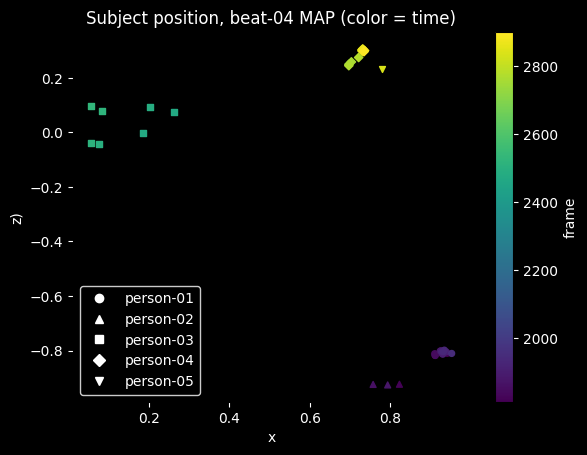

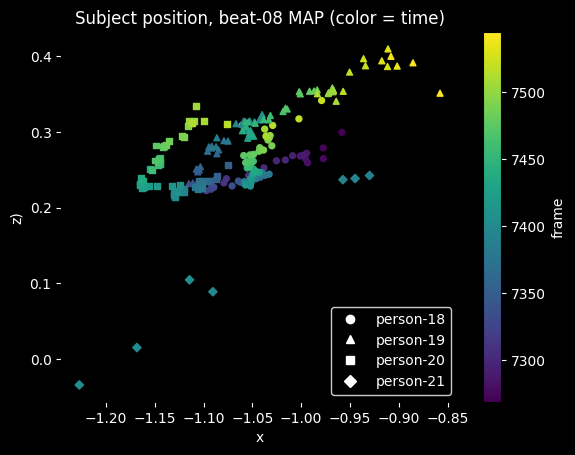

In [27]:
#graph postions 2d - NOT SURE HOW TO USE THIS! POINTLESS FOR THE REPORT!
# One figure per recon -- axes are that recon's own space, so plotting two on one set
# of axes would be meaningless.
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

markers = ["o", "^", "s", "D", "v", "P"]

for job in recon_jobs:
    subj = job.get("subjects_real_pos") or job.get("subjects_positions") or {}
    if not subj:
        print(f"{job['beat_key']} {job['kind']}: no subject positions")
        continue

    fig, ax = plt.subplots()
    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")

    allf    = np.concatenate([np.array(sorted(d)) for d in subj.values()])
    handles = []
    for (slug, d), mk in zip(subj.items(), markers):
        frames = np.array(sorted(d))
        pts    = np.array([d[k] for k in frames])
        sc = ax.scatter(pts[:, 0], pts[:, 2], c=frames, cmap="viridis", marker=mk,
                        vmin=allf.min(), vmax=allf.max(), s=18)   # colour = frame number
        handles.append(Line2D([0], [0], marker=mk, ls="", color="white", label=slug))

    cb = fig.colorbar(sc, ax=ax)
    cb.set_label("frame", color="white")
    cb.ax.yaxis.set_tick_params(color="white", labelcolor="white")

    ax.legend(handles=handles, labelcolor="white", facecolor="black", edgecolor="white")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    ax.set_xlabel("x")
    ax.set_ylabel("z)")
    ax.set_title(f"Subject position, {job['beat_key']} {job['kind']} (color = time)")


In [28]:
if analysis_2d_for_decisions["GPS_signal"] == "yes":
    for job in recon_jobs:
        print(f"--- {job['beat_key']} ---")
        print(job.get("subjects_real_pos", {}).keys())


--- beat-04 MAP ---
{}
--- beat-08 MAP ---
{}


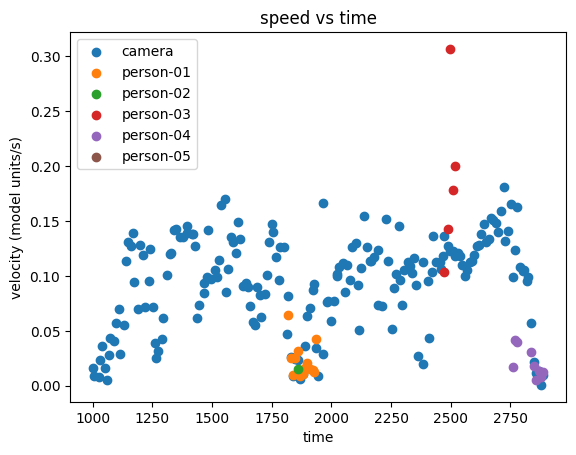

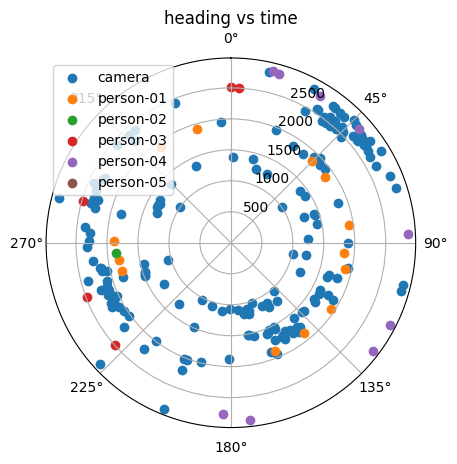

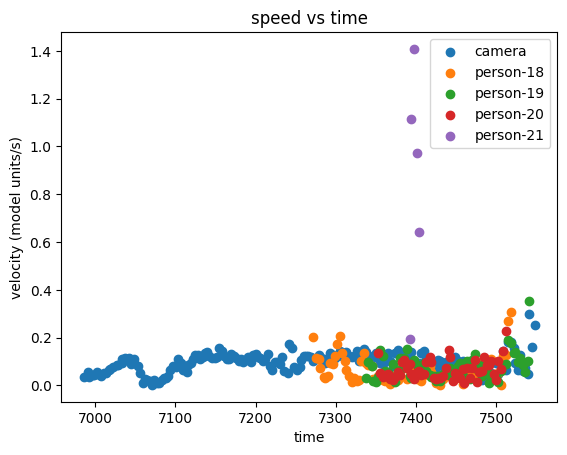

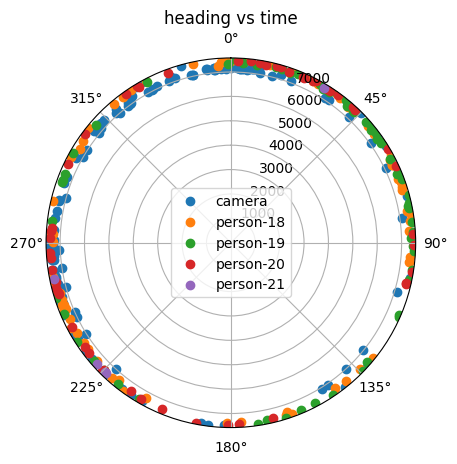

In [29]:
##3D Graphing and analysis METRIC OR NOT - per recon
# Speed/direction and meetings are both distance maths, so they run inside one recon's
# space. A requested pair is only measurable in a recon that actually saw both of them;
# pairs that split across two recons are reported as skipped rather than silently wrong.
from Q_Metric_georeferencing import speed_direction, _speed_direction_single
from Q_subject_analysis import  meeting_calculator
from render_paper_edit import build_meeting_requests

meeting_pairs = build_meeting_requests()   # [["person-1","person-2"], ["person-1","camera"]]

for job in recon_jobs:
    subjects = job.get("subjects_real_pos") or job.get("subjects_positions") or {}
    job["group_metrics"] = speed_direction(
        {"camera": job["cam_poses_model"], **subjects}, fps)

    meetings = {}
    subjects_distance_to_camera = {}
    for A_dict_entry, B_dict_entry in meeting_pairs:
        B_is_camera = B_dict_entry == "camera"
        if A_dict_entry not in subjects or (not B_is_camera and B_dict_entry not in subjects):
            print(f"{job['beat_key']}: skipping {A_dict_entry} vs {B_dict_entry} "
                  f"-- not both present in this recon")
            continue
        A_real_dict = subjects[A_dict_entry]
        B_real_dict = job["cam_poses_model"] if B_is_camera else subjects[B_dict_entry]

        if B_is_camera:
            meeting_report, distance_series = meeting_calculator(
                A_real_dict, A_dict_entry, B_real_dict, B_dict_entry,
                B_is_camera=B_is_camera, return_series=True)
            subjects_distance_to_camera[A_dict_entry] = distance_series
        else:
            meeting_report = meeting_calculator(
                A_real_dict, A_dict_entry, B_real_dict, B_dict_entry,
                B_is_camera=B_is_camera)
        meetings[(A_dict_entry, B_dict_entry)] = meeting_report
    job["meetings"] = meetings
    job["subjects_distance_to_camera"] = subjects_distance_to_camera
    print(f"--- {job['beat_key']} {job['kind']} ---")
    print(meetings)

##TEMP TESTS

## this will be deleted

In [30]:
depth_intersection = False
if depth_intersection == True:
    #depth based intersections checker # TEMP
    #mask overlay sequence: person-1 (green) vs sword (magenta)
    from Two2D.W_video_editor import apply_mask_overlay, _load_mask_bool
    from A_Config import assets_dir, source_video_path
    from pathlib import Path
    import cv2
    A_slug, B_slug = "person-1", "the_large_sword-1"
    def _dirs(slug):
        e = analysis_2d_for_decisions[slug]
        return [Path(d) for d in (e.get("masks_dirs") or [e["masks_dir"]])]
    A_dir, B_dir = _dirs(A_slug)[0], _dirs(B_slug)[0]
    #sword is person 5
    B_dir = Path("/workspace/project/Data/304_met_multi_4/015_SAM3_masks/pipetest_01/person-3")   # the sword



    out_dir = assets_dir() / f"contact_check_{A_slug}_vs_{B_slug}"
    out_dir.mkdir(parents=True, exist_ok=True)

    frames = sorted(set(analysis_2d_for_decisions[A_slug]["Subject_frames_present"]) |
                    set(analysis_2d_for_decisions[B_slug]["Subject_frames_present"]))

    cap = cv2.VideoCapture(str(source_video_path()))
    for f in frames:
        cap.set(cv2.CAP_PROP_POS_FRAMES, f)
        ret, frame = cap.read()
        if not ret:
            continue
        for d, colour in ((A_dir, (0, 200, 0)), (B_dir, (200, 0, 200))):
            m = _load_mask_bool(d, f)
            if m is not None:
                frame = apply_mask_overlay(frame, m, color=colour)
        cv2.imwrite(str(out_dir / f"{f:04d}.png"), frame)
    cap.release()
    print(out_dir, len(frames), "frames")

# TOUCHING TEST
## Needs work  see PHYSICS - NEW FLAGS PLAN MULTI RECON 

In [31]:
# subject touching test
if depth_intersection == True:
    # Manual/WIP cell -- there's no rule yet for which recon a contact test belongs to,
    # so pick the job by hand (see the RECON JOBS cell for what's available).
    from Q_subject_analysis import contact_frames
    job = recon_jobs[0]
    res = contact_frames(job["recon"], A_dir, B_dir)

    r = res[386]          # your contact frame
    plt.plot(list(r["A_profile"]), list(r["A_profile"].values()), "o-", label="A")
    plt.plot(list(r["B_profile"]), list(r["B_profile"].values()), "o-", label="B")
    plt.xlabel("depthels from seam"); plt.ylabel("depth"); plt.legend()
    print(r["depth_gap"], r["fit_resid"], r["contact"])


# PRODUCER 2

In [32]:
#find the cut points
import Two2D.W_video_editor
Two2D.W_video_editor.find_all_cut_points(video_path, analysis_2d_for_decisions)

PosixPath('/workspace/project/Data/402_Hide_n_seek_sw07/012_agent_p_output/v_05/402_Hide_n_seek_sw07_paper_edit_draft.json')

In [33]:
#run producer again
from producer_agent_execution import run_producer_agent, build_producer_prompt_revision

prompt = build_producer_prompt_revision(Question, analysis_2d_for_decisions, producer_flags)
paper_edit_json_path = run_producer_agent(prompt)

[16:28:13 +  0.00s] run_producer_agent: start
[16:28:13 +  0.00s] thread: start
[16:28:13 +  0.00s] event loop: created
[16:28:13 +  0.00s] query: start
[16:28:48 + 35.54s] turn 1 usage (claude-sonnet-5): in=2 out=8 cache_write=33124 cache_read=0
[16:28:48 + 35.54s] turn 1 content blocks: ['ThinkingBlock']
[16:28:48 + 35.54s] thinking:
I notice the 2D analysis data uses numeric person IDs like person-01 through person-21 tied to beat numbers, which doesn't line up cleanly with the PEOPLE list's person-1 through person-8 IDs. I'm trying to figure out how these two numbering schemes map to each other across the beats.

This suggests each beat's tracking actually found multiple people, not just one as the draft assumed — beat-06 detected 3 tracks instead of the single "fourth person," and beat-07 detected 6 tracks instead of just the "fifth person." The transcript around 02:08-02:13 even says "Got one. I got another one," confirming multiple people were found in that window, which contrad

# Rendering
## Point_cloud based

In [34]:
#projection map - one per beat that asked for one
# A projection map is a novel view of a RECON_3D, so it runs on the jobs whose beat
# requested PROJECTION_MAP. Each uses its own recon's cam0 view and its own frame set;
# main_idx is the middle frame of that set rather than a hardcoded number, which would
# only exist in one recon.
if flags["PROJECTION_MAP"] == True:
    from P_projection_mapping import projection_mapping_sequence
    from Two2D.B_video_processing import available_frames

    for job in jobs_of(flag="PROJECTION_MAP"):
        extra_indices = available_frames(job["frames_dir"], FRAME_NAME_FMT)
        print(f"{job['beat_key']}: {extra_indices}")
        job["projection_subject_positions"] = projection_mapping_sequence(
            recon         = job["recon"],
            main_idx      = extra_indices[len(extra_indices) // 2],
            extra_indices = extra_indices,
            masks_dir     = str(yolo_masks_dir),
            new_view      = job["ext"],
            confidence_threshold = 2,
        )
else:
    print("Cell disabled")


Cell disabled


In [35]:
print(analysis_2d_for_decisions)

{'GPS_signal': 'no', 'person-01': {'Subject_frames_present': [1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1823, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866, 1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877, 1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954], 'subject_first_frame': 1810, 'subject_last_frame': 1954, 'subject_d

## Mapping

In [36]:
#make animated map -- one map per GOOGLE_MAP beat. Each writes its own image sequence
# to assets/map_frames_<beat_key> (the standard hand-off to the editor); gif/mp4 are
# optional extra exports of the same frames. Duration comes from the beat we pass in,
# so two MAP beats get two different-length animations instead of sharing one.
if flags["GOOGLE_MAP"] == True:
    import Rendering.R_map_animator

    for job in jobs_of(archetype="MAP", flag="GOOGLE_MAP"):
        subject_traces = [{"coords": latlons, "trail_color": "#e74c3c"}      #subjects
                          for latlons in job.get("subjects_latlon", {}).values()]
        Rendering.R_map_animator.main(
            traces = [
                {"coords": job["cam_latlons"], "trail_color": "#3498db"},     #cameras
                *subject_traces,
            ],
            api_key = api_key,
            beat    = job["beat"],
            gif = True,
            mp4 = None,
        )
else:
    print("Cell disabled")


Cell disabled


In [37]:
#get times of day into the report
from C_CSV_report import attach_times_of_day
report = attach_times_of_day(video_path, 30.07)

In [38]:
#BEV SETUP - the frames each recon actually holds, per job
from P_projection_mapping import projection_mapping_sequence, BEV_tile_render_PM
from AA_cam_pose_sweeps import _render_bev_tiles

from Two2D.B_video_processing import available_frames

#Use this to project every frame in each recon
for job in recon_jobs:
    job["extra_indices"] = available_frames(job["frames_dir"], FRAME_NAME_FMT)
    print(f"{job['beat_key']} {job['kind']}: {len(job['extra_indices'])} frames")


beat-04 MAP: 190 frames
beat-08 MAP: 190 frames


In [39]:
#BEV HI RES - one BEV still per BEV_MAP beat
#BEV projection mapping of subject to a selected view
# BEV_tile_render_PM's default out_path is asset_name-based (one file for the whole
# case), so pass a beat-keyed path in. That also skips its own add_to_asset_list, so
# the beat-keyed asset row is logged here instead.
from A_Config import assets_dir, asset_name, to_report_path
from C_CSV_report import add_to_asset_list

for job in jobs_of(archetype="MAP", flag="BEV_MAP"):
    out_path = assets_dir() / f"{asset_name()}_BEV_tile_render_PM_{job['beat_key']}.png"
    BEV, job["new_view"], job["ortho_params"], job["BEV_path"] = BEV_tile_render_PM(
        job["recon"],
        job["extra_indices"],
        masks_dir = None,
        splat_radius = 1,
        confidence_threshold=np.percentile(conf, 60),
        margin_frac = 0.05,
        out_path = out_path,
    )
    add_to_asset_list({f"BEV_tile_render_PM_{job['beat_key']}": to_report_path(job["BEV_path"])})
    print(f"{job['beat_key']}: {job['BEV_path']}")


min depth tensor(0.0229, device='cuda:0')
torch.Size([13463460, 3])
mins, maxes and ranges -0.8074806183576584 1.0103772729635239 1.8178578913211823 -1.3953451752662658 0.8364064335823059 2.2317516088485716
scale - original 1821.6940885429867
beat-04: /workspace/project/Data/402_Hide_n_seek_sw07/090_assets/402_Hide_n_seek_sw07_v_05_BEV_tile_render_PM_beat-04.png
min depth tensor(0.0340, device='cuda:0')
torch.Size([20078584, 3])
mins, maxes and ranges -1.582699266076088 0.5591101914644241 2.141809457540512 -0.07629033802077174 1.1741677678190172 1.250458105839789
scale - original 2738.0511177832145
beat-08: /workspace/project/Data/402_Hide_n_seek_sw07/090_assets/402_Hide_n_seek_sw07_v_05_BEV_tile_render_PM_beat-08.png


In [40]:
#TRACE OVERLAY Animate the camera (position + heading frustum) over the BEV_tile_render_PM still.
#One animation per BEV_MAP beat, each over its own BEV still. n_frames comes from the beat
#we pass in (duration_seconds * fps), and frames land in bev_trace_frames_<beat_key>.
from P_trace_overlayer import BEV_trace_overlay

for job in jobs_of(archetype="MAP", flag="BEV_MAP"):
    BEV_trace_overlay(
        job["recon"],
        job["extra_indices"],
        job["new_view"],
        job["ortho_params"],
        subject_positions = job.get("subjects_real_pos") or job.get("subjects_positions") or {},
        bev_png_path      = job["BEV_path"],
        beat              = job["beat"],
    )


Skipping subject trace 'person-05' -- only 1 frame(s) overlap extra_indices.
frame 0000 t_frac=0.0000 [camera] virtual_frame=989.0 pos_px=(390.8, 404.8)
frame 0000 t_frac=0.0000 [person-01] virtual_frame=989.0 pos_px=(842.4, 796.6)
frame 0000 t_frac=0.0000 [person-02] virtual_frame=989.0 pos_px=(788.7, 851.7)
frame 0000 t_frac=0.0000 [person-03] virtual_frame=989.0 pos_px=(498.9, 386.9)
frame 0000 t_frac=0.0000 [person-04] virtual_frame=989.0 pos_px=(729.5, 281.8)
frame 0001 t_frac=0.0033 [camera] virtual_frame=995.4 pos_px=(390.3, 404.1)
frame 0001 t_frac=0.0033 [person-01] virtual_frame=995.4 pos_px=(842.4, 796.6)
frame 0001 t_frac=0.0033 [person-02] virtual_frame=995.4 pos_px=(788.7, 851.7)
frame 0001 t_frac=0.0033 [person-03] virtual_frame=995.4 pos_px=(498.9, 386.9)
frame 0001 t_frac=0.0033 [person-04] virtual_frame=995.4 pos_px=(729.5, 281.8)
frame 0002 t_frac=0.0067 [camera] virtual_frame=1001.8 pos_px=(388.9, 403.2)
frame 0002 t_frac=0.0067 [person-01] virtual_frame=1001.8 pos_

In [41]:
import torch
print(torch.is_autocast_enabled())


False


In [46]:
#Make the edited multimedia movie

import Two2D.W_video_editor
 
Two2D.W_video_editor.assemble_paper_edit(video_path, recon_jobs=recon_jobs)

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

making overlay for beat beat-02


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

making overlay for beat beat-03


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

...

making overlay for beat beat-06


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

making overlay for beat beat-09


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

PosixPath('/workspace/project/Data/402_Hide_n_seek_sw07/090_assets/402_Hide_n_seek_sw07_v_05_rough_cut.mp4')

In [43]:
from V_text_summary import gemini_final_report, gemini_cache_video
vid_path = assets_dir() / f"{asset_name()}_rough_cut.mp4"
cache =  gemini_cache_video(vid_path, assets_dir(), ttl="6000s")
gemini_final_report()

On August 15, 2026, at approximately 17:03:33, a group of people are found during a game of hide-and-seek in a paved residential alleyway next to a wooden fence and garden hedges.

The main subject is a young girl highlighted with a green mask, wearing a green dress and carrying two stuffed toy monkeys. She is initially seen hiding behind large green spherical bushes next to a dark wooden building, alongside two older girls. The camera operator (the seeker) walks up to them and happily exclaims, "Aha! Found you! You guys win! Congratulations, you are the best hiders."

The subject, highlighted in green, is observed from 17:03:35 to 17:03:42. During this duration, she moves a net distance of 0.28 model units at a net heading of 64 degrees as she steps forward from her hiding spot toward the camera.
00:00 [Seeker]: 4... 5... 6... 7... 8... 9... 10! Ready or not, here I come.

00:17 [Seeker]: Oh. I can see a human.

00:24 [Seeker]: Aha! Caught you. You've been found.

00:28 [First Hider]:

In [44]:
timer_end()

NameError: name 'timer_end' is not defined

In [ ]:
# Cell — Populate PowerPoint from CSV
import importlib

import W_populate_pptx
importlib.reload(W_populate_pptx)
from W_populate_pptx import populate



report_template = project_root / "src" / "Powerpoint" / f"{ppt_template}.pptx"
ppt_assets   = case_dir / "090_Assets"
ppt_csv      = ppt_assets / f"{case_name}.csv"
ppt_output   = case_dir / "100_Powerpoint" / f"{case_name}.pptx"


populate(str(report_template))